### Updated Problem Statement After Feedback

Accurate next‑day rainfall prediction is critical for risk management in outdoor events. National weather services such as the Bureau of Meteorology (BOM) already provide regional forecasts, but their information is often spread across multiple products (text forecasts, maps, tables) and is not directly optimized for the specific decision an event coordinator cares about: “Given current conditions, how likely is it that it will rain at my event location tomorrow?”

This project aims to build a supervised classification model that predicts whether it will rain tomorrow (rain vs. no rain) at a given BOM weather‑station location, using weather variables measured on the current day. We will use the publicly available Kaggle “Weather in Australia” dataset, which contains daily meteorological observations (e.g., temperature, humidity, wind, pressure, rainfall) and a binary target variable indicating whether rain was recorded the next day.

To construct this model, we will use TPOT (Tree‑based Pipeline Optimization Tool), a genetic‑programming‑based AutoML library that automatically searches over combinations of preprocessing steps, model families, and hyperparameters. TPOT will be configured to optimize pipelines using cross‑validated performance measures that reflect our main objective: accurately identifying days when rain will occur.

Rather than claiming to improve the underlying meteorological accuracy over BOM, our goal is to repurpose historical station data into a decision‑support tool tailored for event organizers. The model’s outputs can be wrapped in an application that:

  - Expresses the risk of rain as simple probabilities and risk categories (e.g., “low / moderate / high” risk of rain tomorrow at this station), and  
  - Emphasizes avoiding missed rain events (false negatives), which are particularly costly for outdoor events.

Because rain events are less frequent than non‑rain events, we will evaluate the model with metrics appropriate for imbalanced classification problems, including recall, F1‑score, and area under the ROC curve (AUROC), in addition to overall accuracy. In configuring TPOT and assessing the final model, we explicitly prioritize high recall for the “rain tomorrow” class to minimize false negatives (cases where the model predicts “no rain” but rain actually occurs). The scope of this project is limited to predicting the occurrence of rain (rain vs. no rain) on the next day; the intensity, duration, or exact amount of rainfall are out of scope.

### Changes Made

- B/C we can not provide better data, our value proposition is giving a tool that is more tailored to even organizers to help them make decisions faster. This is acomplished by a clear single output
- Removal of fine grained accuracy b/c we are using the same datasets that larger weather services can use
- Point of the project is no longer to give a better forcast, but one that is decision support layer
- We explicitly call our false negatives as being important to avoid to better this decision layer
- Includes TPOT in it (could replace with MLJAR if needed)


### What did the research tell you? What ended up being your goal/solution

Our research told us that
- classification is appropriate: all three papers found that classification model are well suited for next day rain fall applications
- We would expect tree based models to work best
- Because no rain days happen more frequently than rain days, all three papers mentioned the importance of evaluating recall, F1-score, and AUROC rather than accuracy alone.

### Our goal and solution

Based on our findings, our goal is to build a binary classification model optimized for recall on "rain tomorrow". We will use TPOT and AutoML to test multiple models with the expectation that the best performing models will be tree-based or ensmble. Rather than trying to out perform government organizations, we are going to build a decision support tool that presents rain categories tailored to event planning decisions

### Does your prediction match with expectation using autoML?

Partially yes. We configured our TPOT flow to optimize for recall b/c of the importance of recalls to prevent false positives. TPOT did an excellent job at doing this improving recall drastically from our baseline model.

However, the model selected from TPOT was not a tree based classifier as expected from our research. This can be explained however from our TPOT hyperparamaters. We chose certain ones to optimize our runs for speed. Potentially allowing it to run for longer and exploring the space more would see it selecting a tree based model.

### What were research results

Imbalanced data: All three papers showed that rain events are less frequent, requiring metrics like recall, F1, and AUROC rather than accuracy alone.

Tree-based models are robust: Papers 1, 2, and 3 all found ensemble or tree-based methods (Random Forest, PART) to be strong performers.

Regional/climate factors matter: Paper 3 specifically found that model performance varies significantly by climate type, with sub-tropical regions (like most of Australia in our dataset) showing better predictability.

Feature importance: Pressure, humidity, temperature, and wind speed were identified as the most important predictors in Papers 1 and 3.

### Do we have results of our own yet?

Our final evaluation compared a Logistic Regression baseline against a TPOT AutoML-selected classifier. Logistic Regression achieved higher overall accuracy (0.698) but very low recall for the rain class (0.158), meaning it missed most rain events. TPOT AutoML produced lower accuracy (0.597) but substantially higher recall for rain (0.682) and a better F1-score (0.509). Since the project prioritizes minimizing false negatives (missed rain events), the TPOT AutoML model is selected as the final model despite its lower accuracy.

### What are you trying to do to meet your end goal/solution

Phase 1. Data Preperation
Phase 2. AutoML Model Selection with TPOT
Phase 3. Evaluation with Imbalanced Metrics
Phase 4. Threshold tuning
Phase 5. Wrap model in a simple interface that shows
- Probability % of rain tomorrow
- Risk category (low, medium or high)
- Actionable Recommendation


## How to run this notebook
Place the file Australia Rainfall.xlsx in the same folder as this notebook before running.

This notebook will generate rainfall_clean.csv.

In [21]:
!pip install -q tpot

In [22]:
# Data set cleaning
import pandas as pd
import numpy as np
import os

RAW_PATH = "Australia Rainfall.csv"

df = pd.read_csv(RAW_PATH)
print(df.shape)

df.info()

df.isna().sum().sort_values(ascending=False).head(15)

# Creating clened copy
df_clean = df.copy()

# Sorting the data
df_clean = df_clean.sort_values(by=["Station", "Year", "Month", "Day"]).reset_index(drop=True)

# Creating "RainTomorrow" from next day's rainfall
df_clean["RainTomorrow"] = df_clean.groupby("Station")["Rain(mm)"].shift(-1)

# Dropping rows where next day doesn't exist
df_clean = df_clean.dropna(subset=["RainTomorrow"])

# Converting to binary (rain tomorrow or not)
df_clean["RainTomorrow"] = (df_clean["RainTomorrow"] > 0).astype(int)

print("\nTarget distribution:")
print(df_clean["RainTomorrow"].value_counts())

# Dropping unnecessaary columns
if "Rain(Y/N)" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Rain(Y/N)"])

# Dropping date column
if "Date" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Date"])

# Evam (mm) is only present on a small percentage of columns in our dataset
# Sun(Hours) is also only present on a small percentage of columns
# Cld 8th is a measure of how many '8ths' of the sky is covered in clouds. We drop this b/c
#      - Lots of missing data points
#      - This reading is a visual reading and is subjective. Better to focus on better data points
cols_to_drop = ["Evap (mm)", "Sun(Hours)", "Cld 8th- 9:00 AM", "Cld 8th- 3:00 PM"]
df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])

# Drop wind direction columns
# We drop wind direction b/c it has a lot of different options (N,S,E,W,NNE,NNW ect...) when we encode this it will have many values
# Wind direction not a key driver - wind speed is much more important (fast changing speeds imply a weather system is coming in)
wind_dir_cols = ["Max Wind gust Dir", "Dir - 9:00 AM - km/h", "Dir - 3:00 PM - km/h"]
df_clean = df_clean.drop(columns=[c for c in wind_dir_cols if c in df_clean.columns])

# Dropping max wind gust time for similar reasons as above. Time of day is not important, but speed is.
time_cols = [c for c in df_clean.columns if c.startswith("Max wind gust-Time-local")]
df_clean = df_clean.drop(columns=time_cols, errors="ignore")

# Dropping station, day and year columns. These are not useful for our model and will add noise.
date_cols = ["Station", "Day", "Year"]
df_clean = df_clean.drop(columns=[c for c in date_cols if c in df_clean.columns])

# Handling missing values
num_cols = df_clean.select_dtypes(include=["float64", "int64"]).columns
num_cols = [c for c in num_cols if c != "RainTomorrow"]
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

cat_cols = df_clean.select_dtypes(include="object").columns
df_clean[cat_cols] = df_clean[cat_cols].fillna("Unknown")

print("Total missing values after cleaning:", df_clean.isna().sum().sum())

# Encoding
cat_cols = df_clean.select_dtypes(include="object").columns
df_final = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Removing duplicates
df_final = df_final.drop_duplicates()

# Removing constant columns
constant_cols = [c for c in df_final.columns if c != "RainTomorrow" and df_final[c].nunique() <= 1]
df_final = df_final.drop(columns=constant_cols)

print("\nTarget %:")
print((df_final["RainTomorrow"].value_counts(normalize=True) * 100).round(2))

print("\nTotal missing in final dataset:", df_final.isna().sum().sum())

df_final.info()

# Saving the dataset
CLEAN_PATH = "rainfall_clean.csv"

df_final.to_csv(CLEAN_PATH, index=False)
print("Saved:", CLEAN_PATH)

(11848, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11848 entries, 0 to 11847
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   State                     11848 non-null  object 
 1   Station                   11848 non-null  object 
 2   Year                      11848 non-null  int64  
 3   Month                     11848 non-null  object 
 4   Date                      11846 non-null  float64
 5   Day                       11846 non-null  object 
 6   Min °C                    11736 non-null  float64
 7   Max °C                    11697 non-null  float64
 8   Rain(mm)                  11652 non-null  float64
 9   Evap (mm)                 2576 non-null   float64
 10  Sun(Hours)                2056 non-null   float64
 11  Max Wind gust Dir         10789 non-null  object 
 12  Max wind gust Spd - km/h  10789 non-null  float64
 13  Max wind gust-Time-local  10797 non-null  object 

In [23]:
from tpot import TPOTClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    make_scorer, recall_score, accuracy_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df_final = pd.read_csv(CLEAN_PATH)

X = df_final.drop(columns=["RainTomorrow"])
y = df_final["RainTomorrow"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Define recall scorer
recall_rain_scorer = make_scorer(recall_score, pos_label=1)

# Baseline model
print("\n" + "="*60)
print("BASELINE MODEL: LOGISTIC REGRESSION")
print("="*60)

baseline_model = LogisticRegression(max_iter=5000)
baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
recall_base = recall_score(y_test, y_pred_base, pos_label=1)
f1_base = f1_score(y_test, y_pred_base, pos_label=1)
roc_base = roc_auc_score(y_test, y_proba_base)

print(f"Accuracy:  {acc_base:.3f}")
print(f"Recall:    {recall_base:.3f}")
print(f"F1 Score:  {f1_base:.3f}")
print(f"ROC-AUC:   {roc_base:.3f}")

# TPOT AutoML

tpot = TPOTClassifier(
    generations=3,              # Reduced from 5
    population_size=10,         # Reduced from 20
    scorers=recall_rain_scorer,
    cv=3,                       # Reduced from 5
    max_eval_time_mins=3,       
    verbose=2,
    random_state=42,
    n_jobs=1                    # Single-threaded
)

# tpot = TPOTClassifier(
#     generations=1,
#     population_size=3,
#     search_space='linear-light',
#     scorers=recall_rain_scorer,
#     cv=2,
#     max_eval_time_mins=0.2,
#     verbose=2,
#     random_state=42,
#     n_jobs=1
# )

tpot.fit(X_train, y_train)


BASELINE MODEL: LOGISTIC REGRESSION
Accuracy:  0.696
Recall:    0.111
F1 Score:  0.183
ROC-AUC:   0.662


/opt/anaconda3/envs/general-ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/envs/general-ml/lib/python3.12/site-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
/opt/anaconda3/envs/general-ml/lib/python3.12/site-packages/distribut

,search_space,<tpot.search_...t 0x348d2b4a0>
,scorers,"make_scorer(r..., pos_label=1)"
,scorers_weights,[1]
,cv,3
,other_objective_functions,[]
,other_objective_functions_weights,[]
,objective_function_names,None
,bigger_is_better,True
,categorical_features,None
,memory,None
,preprocessing,False



TPOT MODEL EVALUATION
Best Pipeline:
Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                ('rfe',
                 RFE(estimator=ExtraTreesClassifier(bootstrap=np.False_,
                                                    criterion=np.str_('gini'),
                                                    max_features=0.4503212524738,
                                                    min_samples_leaf=4,
                                                    min_samples_split=7,
                                                    n_jobs=1, random_state=42),
                     step=0.9162776237062)),
                ('featureunion-1',
                 FeatureUnion(transformer_list=[('featureunion',
                                                 FeatureUnion(transformer_list=[(...
                                                ('passthrough',
                                                 Passthrough())])),
                ('featureunion-2',
                 FeatureUnion(tr

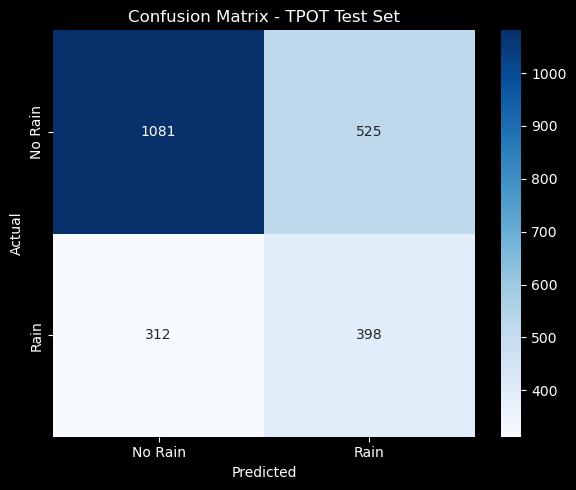

In [24]:
# TPOT test evaluation
print("\n" + "="*60)
print("TPOT MODEL EVALUATION")
print("="*60)

# Check what model TPOT selected
print("Best Pipeline:")
print(tpot.fitted_pipeline_)


y_pred_tpot = tpot.predict(X_test)
y_proba_tpot = tpot.predict_proba(X_test)[:, 1]

acc_tpot = accuracy_score(y_test, y_pred_tpot)
recall_tpot = recall_score(y_test, y_pred_tpot, pos_label=1)
f1_tpot = f1_score(y_test, y_pred_tpot, pos_label=1)
roc_tpot = roc_auc_score(y_test, y_proba_tpot)

print(f"Accuracy:  {acc_tpot:.3f}")
print(f"Recall:    {recall_tpot:.3f}")
print(f"F1 Score:  {f1_tpot:.3f}")
print(f"ROC-AUC:   {roc_tpot:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tpot, target_names=['No Rain', 'Rain']))

# Confusion matrix for TPOT
cm = confusion_matrix(y_test, y_pred_tpot)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rain', 'Rain'],
            yticklabels=['No Rain', 'Rain'])
plt.title('Confusion Matrix - TPOT Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [25]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'TPOT AutoML'],
    'Accuracy': [acc_base, acc_tpot],
    'Recall': [recall_base, recall_tpot],
    'F1 Score': [f1_base, f1_tpot],
    'ROC-AUC': [roc_base, roc_tpot]
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))


MODEL COMPARISON
              Model  Accuracy   Recall  F1 Score  ROC-AUC
Logistic Regression  0.696028 0.111268  0.183295 0.661930
        TPOT AutoML  0.638601 0.560563  0.487446 0.674643


## Citations

Ejike, O., Ndzi, D., & Shakir, M. Z. (2025). Comparative Study of Machine Learning-Based Rainfall Prediction in Tropical and Temperate Climates. Climate, 13(8), 167. https://doi.org/10.3390/cli13080167

Samadianfard, S. (2022). Evaluation of classification and decision trees in predicting daily precipitation occurrences. Water Supply, 22(4), 3879–3895. https://iwaponline.com/ws/article/22/4/3879/86271/Evaluation-of-classification-and-decision-trees-in

Sarasa-Cabezuelo, A. (2022). Prediction of Rainfall in Australia Using Machine Learning. Information, 13(4), 163. https://doi.org/10.3390/info13040163

## Disclosure

Portions of this assignment were developed with the assistance of a generative artificial intelligence tool. The tool was used to help brainstorm ideas, refine wording, and improve clarity and organization of the writing. All sources cited were selected and reviewed by us, and we verified the accuracy of the final content, citations, and formatting. We take full responsibility for the final submission.

## Export Model for Deployment

In [29]:
import joblib
import os
from sklearn.base import clone

# Create assignment_3 directory if it doesn't exist
output_dir = "../assignment_3"
os.makedirs(output_dir, exist_ok=True)

# Extract the pure sklearn pipeline from TPOT (removing TPOT dependencies)
# We'll retrain it on the full training data to ensure it's a clean sklearn object
sklearn_pipeline = tpot.fitted_pipeline_

# Create a fresh sklearn pipeline by cloning and refitting
# This removes any TPOT-specific wrappers
from sklearn.base import clone
clean_pipeline = clone(sklearn_pipeline)
clean_pipeline.fit(X_train, y_train)

# Now save the clean sklearn pipeline
model_path = os.path.join(output_dir, "rain_predictor_model.pkl")
joblib.dump(clean_pipeline, model_path)
print(f"✓ Model saved to: {model_path}")

# Verify it works
test_pred = clean_pipeline.predict(X_test[:1])
print(f"✓ Model verification: prediction test passed")

# Save preprocessing info (feature names and medians for imputation)
preprocessing_info = {
    'feature_names': list(X_train.columns),
    'numeric_medians': df_clean[num_cols].median().to_dict() if 'num_cols' in locals() else {},
    'categorical_columns': list(cat_cols) if 'cat_cols' in locals() else []
}

preprocessing_path = os.path.join(output_dir, "preprocessing_info.pkl")
joblib.dump(preprocessing_info, preprocessing_path)
print(f"✓ Preprocessing info saved to: {preprocessing_path}")

print("\nModel export complete! Ready for Streamlit deployment.")
print(f"Exported as pure sklearn - NO TPOT needed for deployment!")

✓ Model saved to: ../assignment_3/rain_predictor_model.pkl
✓ Model verification: prediction test passed
✓ Preprocessing info saved to: ../assignment_3/preprocessing_info.pkl

Model export complete! Ready for Streamlit deployment.
Exported as pure sklearn - NO TPOT needed for deployment!


In [30]:
!pip show tpot

Name: TPOT
Version: 1.1.0
Summary: Tree-based Pipeline Optimization Tool
Home-page: https://github.com/EpistasisLab/tpot
Author: Pedro Ribeiro
Author-email: 
License: GNU/LGPLv3
Location: /opt/anaconda3/envs/general-ml/lib/python3.12/site-packages
Requires: configspace, dask, dask-expr, dask-jobqueue, dill, distributed, func-timeout, joblib, lightgbm, matplotlib, networkx, numpy, optuna, pandas, scikit-learn, scipy, seaborn, stopit, tqdm, traitlets, update-checker, xgboost
Required-by: 
